In [20]:
import pickle
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
from pathfinding.core.diagonal_movement import DiagonalMovement

In [21]:
# Estado inicial de la simulación reset para las vacantes

with open(f'Results/Last_Configuration_forming_0.pkl', 'rb') as file:
    # Carga el contenido del archivo
    initial_configuration = pickle.load(file)

In [22]:
import numpy as np


def all_paths(configuration_matrix: np.ndarray) -> list:
    # obtengo las dimensiones de la matriz
    _, Ejey = configuration_matrix.shape

    # Lista para almacenar todos los caminos
    all_paths_list = []

    # Compruebo si hay trampas en la primera y última columna
    if 1 in configuration_matrix[:, 0] and 1 in configuration_matrix[:, -1]:
        # obtengo las posiciones de los 1 en la primera columna
        start = np.where(configuration_matrix[:, 0] == 1)[0]

        # Creo la lista de nodos de inicio sabiendo que todos los nodos de inicio están en la primera columna
        start = [(i, 0) for i in start]

        # obtengo las posiciones de los 1 en la última columna
        end = np.where(configuration_matrix[:, -1] == 1)[0]

        for k in [1, 2]:
            # obtengo las posiciones de los 1 en la última columna
            end = np.where(configuration_matrix[:, -k] == 1)[0]

            # Creo la lista de nodos de fin sabiendo que todos los nodos de fin están en la última columna en forma de grid node
            end = [(i, Ejey - k) for i in end]

            # Recorro los nodos de inicio y fin para ver si hay camino
            finder = AStarFinder(diagonal_movement=DiagonalMovement.never)

            for i in start:
                for j in end:
                    grid = Grid(matrix=configuration_matrix)

                    node_start = grid.node(i[1], i[0])
                    node_end = grid.node(j[1], j[0])

                    path, runs = finder.find_path(node_start, node_end, grid)
                    if len(path) > 0:
                        # Convert path to a numpy array of tuples
                        path_tuples = np.array([(node.x, node.y) for node in path])
                        all_paths_list.append(path_tuples)

    return all_paths_list


# Uso de la función con la matriz de configuración inicial
percolation_paths = all_paths(initial_configuration)

print(percolation_paths)

[array([[ 0,  0],
       [ 1,  0],
       [ 2,  0],
       [ 3,  0],
       [ 4,  0],
       [ 5,  0],
       [ 6,  0],
       [ 7,  0],
       [ 8,  0],
       [ 9,  0],
       [10,  0],
       [11,  0],
       [12,  0],
       [13,  0],
       [14,  0],
       [15,  0],
       [16,  0],
       [17,  0],
       [18,  0],
       [19,  0],
       [20,  0],
       [21,  0],
       [22,  0],
       [23,  0],
       [24,  0],
       [25,  0],
       [26,  0],
       [27,  0],
       [28,  0],
       [29,  0],
       [30,  0],
       [31,  0],
       [32,  0],
       [33,  0],
       [34,  0],
       [35,  0],
       [36,  0],
       [37,  0],
       [38,  0],
       [39,  0]]), array([[ 0,  5],
       [ 1,  5],
       [ 1,  6],
       [ 2,  6],
       [ 3,  6],
       [ 4,  6],
       [ 5,  6],
       [ 6,  6],
       [ 7,  6],
       [ 8,  6],
       [ 9,  6],
       [10,  6],
       [11,  6],
       [12,  6],
       [13,  6],
       [14,  6],
       [15,  6],
       [16,  6],
       [17,

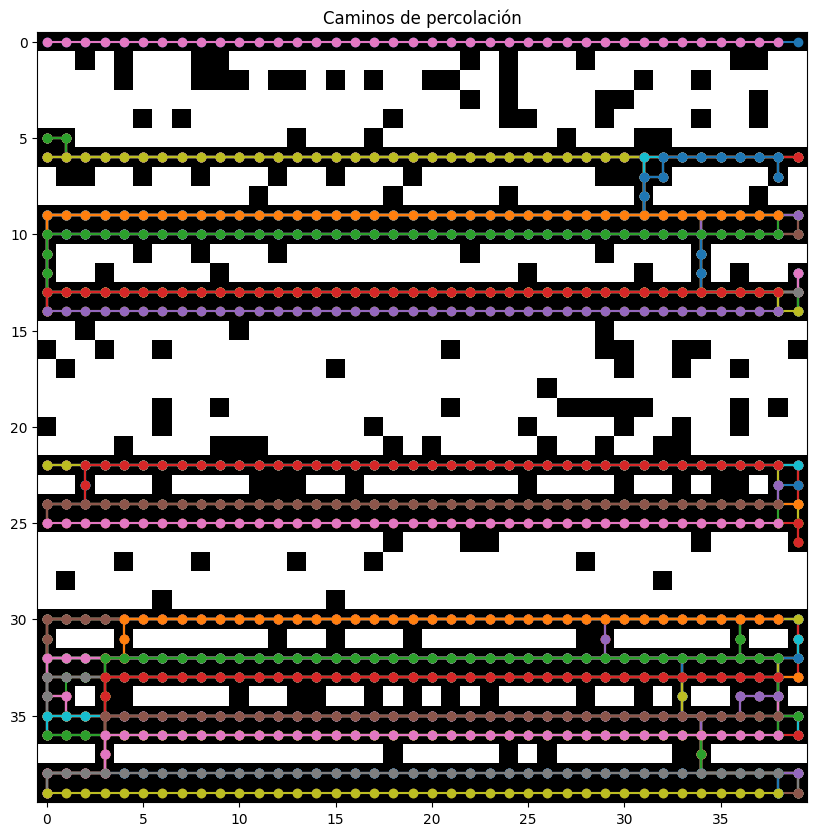

In [23]:
def plot_percolation_paths(configuration_matrix: np.ndarray, paths: list):
    plt.figure(figsize=(10, 10))
    plt.imshow(configuration_matrix, cmap='Greys', interpolation='none')

    for path in paths:
        path = np.array(path)
        plt.plot(path[:, 0], path[:, 1], marker='o')

    plt.title('Caminos de percolación')
    plt.show()


# Uso de la función con la matriz de configuración inicial y los caminos de percolación
plot_percolation_paths(initial_configuration, percolation_paths)

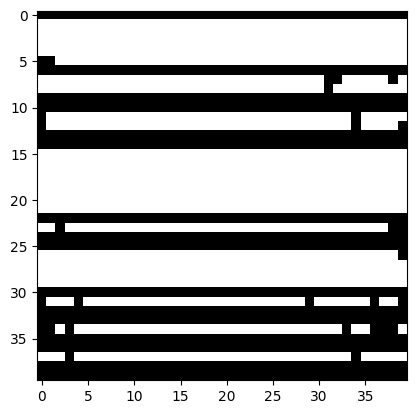

In [24]:
def generate_percolation_matrix(configuration_matrix: np.ndarray, paths: list) -> np.ndarray:
    # Crear una matriz de ceros del mismo tamaño que la configuración inicial
    percolation_matrix = np.zeros_like(configuration_matrix)

    # Iterar sobre cada camino de percolación y marcar las posiciones en la matriz
    for path in paths:
        for (x, y) in path:
            percolation_matrix[y, x] = 1

    return percolation_matrix


# Generar la matriz de percolación
percolation_matrix = generate_percolation_matrix(initial_configuration, percolation_paths)

plt.imshow(percolation_matrix, cmap='Greys', interpolation='none')

In [27]:
from pathfinding.core.grid import Grid
from pathfinding.core.diagonal_movement import DiagonalMovement
from pathfinding.finder.a_star import AStarFinder


def find_all_paths(grid, start, end):
    paths = []
    stack = [(start, [start])]

    while stack:
        (node, path) = stack.pop()
        for next_node in grid.neighbors(node, DiagonalMovement.never):
            if next_node in path:
                continue
            if next_node == end:
                paths.append(path + [next_node])
            else:
                stack.append((next_node, path + [next_node]))

    return paths


grid = Grid(matrix=initial_configuration)
start = grid.node(22, 0)
end = grid.node(22, 39)

# Encontrar todos los caminos
all_paths = find_all_paths(grid, start, end)

for path in all_paths:
    print([node for node in path])